In [9]:
# 1. Inicialización procesamiento con POLARS

In [10]:
import os
import polars as pl
import time
import plotly.graph_objects as go

ruta_input = "../data/incendios_global_consolidado.parquet"

def cargar_datos_completos(ruta):
    if not os.path.exists(ruta):
        print(f"No encontrado: {ruta}")
        return None
    
    print(f"Cargando: {ruta}")
    
    df = (
        pl.scan_parquet(ruta)
        .collect(engine="streaming")
    )
    
    print(f"Cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")
    return df

# Cargar el archivo global completo
df_global = cargar_datos_completos(ruta_input)

# Mostrar informacion adicional
if df_global is not None:
    print("\nRESUMEN DEL DATASET GLOBAL:")
    print(f"   - Total de registros: {df_global.shape[0]:,}")
    print(f"   - Columnas: {df_global.shape[1]}")
    print(f"   - Rango de fechas: {df_global['acq_date'].min()} a {df_global['acq_date'].max()}")
    print("\nEsquema de datos:")
    for col, dtype in df_global.schema.items():
        nulos = df_global[col].null_count()
        print(f"   {col:<20} {str(dtype):<15} nulos: {nulos:,}")


Cargando: ../data/incendios_global_consolidado.parquet
Cargado: 52,508,485 filas, 14 columnas

RESUMEN DEL DATASET GLOBAL:
   - Total de registros: 52,508,485
   - Columnas: 14
   - Rango de fechas: 2025-06-30 a 2026-06-30

Esquema de datos:
   acq_date             Date            nulos: 0
   frp                  Float64         nulos: 0
   satellite            String          nulos: 0
   brightness           Float64         nulos: 0
   scan                 Float64         nulos: 0
   acq_time             Int64           nulos: 0
   bright_t31           Float64         nulos: 0
   track                Float64         nulos: 0
   daynight             String          nulos: 0
   latitude             Float64         nulos: 0
   version              String          nulos: 0
   longitude            Float64         nulos: 0
   confidence           String          nulos: 0
   instrument           String          nulos: 0


In [11]:
#  2 Medición de rendimiento Polars

In [12]:
import time

print("METRICAS DE RENDIMIENTO - POLARS (Streaming Engine)")
print("=" * 60)

ruta_input = "../data/incendios_global_consolidado.parquet"

# Medir tiempo de carga completa
inicio = time.perf_counter()
df_test = (
    pl.scan_parquet(ruta_input)
    .collect(engine="streaming")
)
fin = time.perf_counter()
t_carga = fin - inicio

tamaño_mb = os.path.getsize(ruta_input) / (1024 * 1024)
throughput_filas = df_test.shape[0] / t_carga
throughput_mb = tamaño_mb / t_carga

print(f"Archivo: {ruta_input}")
print(f"Tamaño en disco: {tamaño_mb:.2f} MB")
print(f"Registros cargados: {df_test.shape[0]:,}")
print(f"Tiempo de carga: {t_carga:.3f} segundos")
print(f"Throughput: {throughput_filas:,.0f} filas/segundo")
print(f"Throughput: {throughput_mb:.2f} MB/segundo")



METRICAS DE RENDIMIENTO - POLARS (Streaming Engine)
Archivo: ../data/incendios_global_consolidado.parquet
Tamaño en disco: 1270.76 MB
Registros cargados: 52,508,485
Tiempo de carga: 0.236 segundos
Throughput: 222,346,540 filas/segundo
Throughput: 5381.01 MB/segundo


In [13]:
# 3 Grafico METRICAS DE RENDIMIENTO

Tamanio del archivo: 1270.76 MB
------------------------------------------------------------
Operacion                 Tiempo(s)    Filas           Throughput
------------------------------------------------------------
Carga completa            0.262        52,508,485      200,595,589 filas/s
Filtro confidence         0.254        52,508,485      206,833,898 filas/s
Agregacion satelite       0.111        52,508,485      471,381,336 filas/s


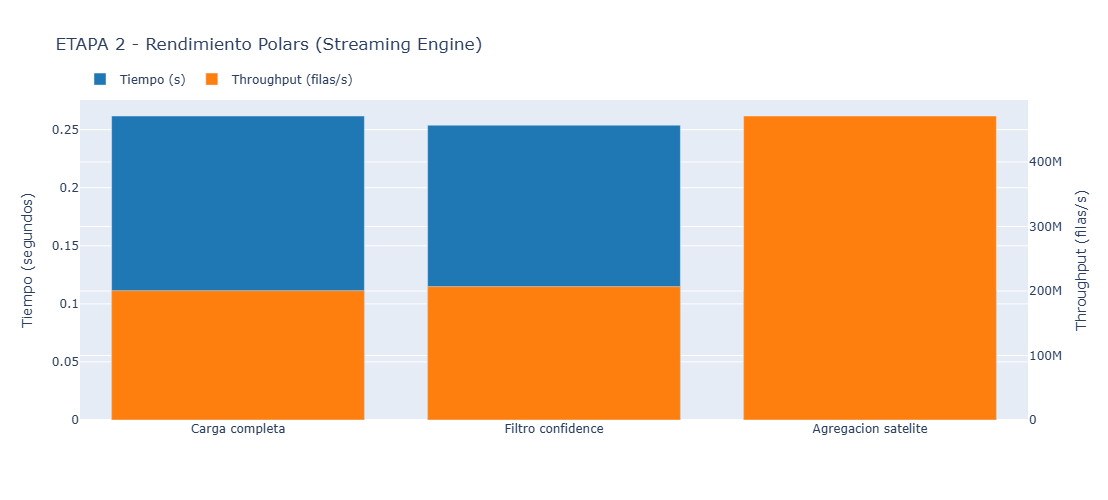

In [14]:
ruta = "../data/incendios_global_consolidado.parquet"
tamanio_mb = os.path.getsize(ruta) / (1024 * 1024)
resultados = {}

# Operacion 1: Carga completa
t0 = time.perf_counter()
df1 = pl.scan_parquet(ruta).collect(engine="streaming")
resultados["Carga completa"] = {
    "tiempo": time.perf_counter() - t0,
    "filas": df1.shape[0]
}

# Operacion 2: Filtrado por confidence
t0 = time.perf_counter()
df2 = pl.scan_parquet(ruta).filter(
    pl.col("confidence").cast(pl.Utf8) != "low"
).collect(engine="streaming")
resultados["Filtro confidence"] = {
    "tiempo": time.perf_counter() - t0,
    "filas": df2.shape[0]
}

# Operacion 3: Agregacion por satelite
t0 = time.perf_counter()
df3 = pl.scan_parquet(ruta).group_by("satellite").agg(
    pl.len().alias("total")
).collect(engine="streaming")
resultados["Agregacion satelite"] = {
    "tiempo": time.perf_counter() - t0,
    "filas": df1.shape[0]  # filas leidas para la agregacion
}

# Imprimir metricas
print(f"Tamanio del archivo: {tamanio_mb:.2f} MB")
print("-" * 60)
print(f"{'Operacion':<25} {'Tiempo(s)':<12} {'Filas':<15} {'Throughput'}")
print("-" * 60)
for nombre, datos in resultados.items():
    tp = datos["filas"] / datos["tiempo"]
    print(f"{nombre:<25} {datos['tiempo']:<12.3f} {datos['filas']:<15,} {tp:,.0f} filas/s")

# Grafico comparativo
nombres = list(resultados.keys())
tiempos = [resultados[n]["tiempo"] for n in nombres]
throughput = [resultados[n]["filas"] / resultados[n]["tiempo"] for n in nombres]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=nombres,
    y=tiempos,
    name="Tiempo (s)",
    marker_color="#1f77b4",
    yaxis="y"
))

fig.add_trace(go.Bar(
    x=nombres,
    y=throughput,
    name="Throughput (filas/s)",
    marker_color="#ff7f0e",
    yaxis="y2"
))

fig.update_layout(
    title="ETAPA 2 - Rendimiento Polars (Streaming Engine)",
    yaxis=dict(title="Tiempo (segundos)", side="left"),
    yaxis2=dict(title="Throughput (filas/s)", side="right", overlaying="y"),
    barmode="group",
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)

fig.show()